# CorrDiff-Mini: Loading with Groups and Exploration

Use `xarray` with the NetCDF4 engine to open each group (`input`, `output`, `invariant`) and inspect variables.

In [2]:
import xarray as xr
import matplotlib.pyplot as plt

# Define file path
nc_path = 'corrdiff_output.nc'

In [7]:
# Open groups using netcdf4 engine
ds_input = xr.open_dataset(nc_path, group='input', engine='netcdf4')
ds_truth = xr.open_dataset(nc_path, group='truth', engine='netcdf4')
ds_pred = xr.open_dataset(nc_path, group='prediction', engine='netcdf4')

In [8]:
# Inspect dimensions and variables
print('Input dims:', ds_input.dims)
print('Input variables:', list(ds_input.data_vars))

print('\ntruth dims:', ds_truth.dims)
print('truth variables:', list(ds_truth.data_vars))


print('\nprediction:', ds_pred.dims)
print('Invariant variables:', list(ds_pred.data_vars))

Input dims: FrozenMappingWarningOnValuesAccess({'time': 1, 'y': 64, 'x': 64})
Input variables: ['u10m', 'v10m', 't2m', 'tcwv', 'sp', 'msl', 'u1000', 'u850', 'u500', 'u250', 'v1000', 'v850', 'v500', 'v250', 'z1000', 'z850', 'z500', 'z250', 't1000', 't850', 't500', 't250', 'q1000', 'q850', 'q500', 'q250', 'elev_mean', 'lsm_mean']

truth dims: FrozenMappingWarningOnValuesAccess({'time': 1, 'y': 64, 'x': 64})
truth variables: ['10u', '10v', '2t', 'tp']

prediction: FrozenMappingWarningOnValuesAccess({'ensemble': 2, 'time': 1, 'y': 64, 'x': 64})
Invariant variables: ['10u', '10v', '2t', 'tp']


算 preciptation 的 mean, variance

AttributeError: 'QuadMesh' object has no attribute 'set_title'

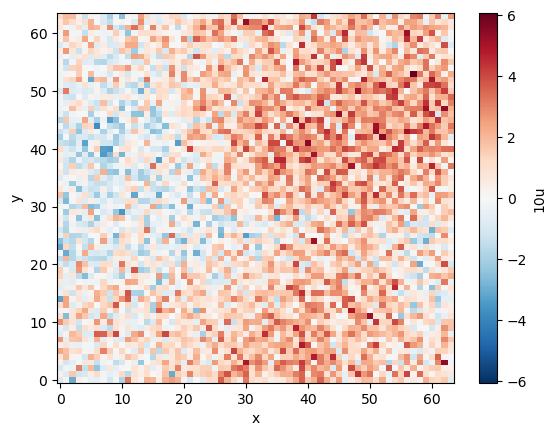

In [ ]:
import matplotlib.pyplot as plt

da = ds_pred['10u'].isel(ensemble=0, time=0)
da.plot()                 # returns a QuadMesh, but also creates axes
plt.title('Pred 10u at ens=0, time=0')
plt.show()

In [12]:
# Example: plot low-resolution 10m wind component u10m at sample index 0
ds_pred['10u'].isel(sample=0).plot()
plt.title('Pred u10m at sample=0')
plt.show()

ValueError: Dimensions {'sample'} do not exist. Expected one or more of ('ensemble', 'time', 'y', 'x')

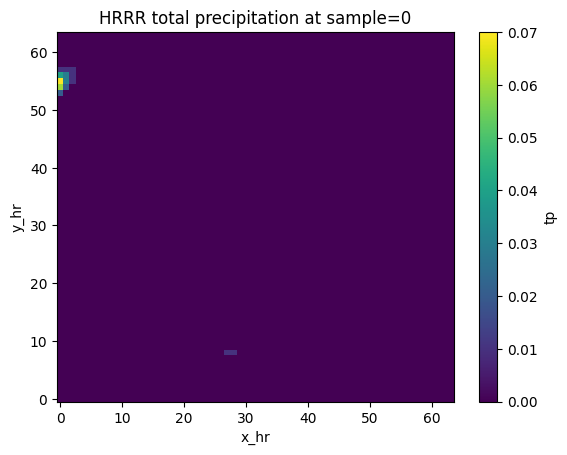

In [5]:
# Example: plot high-resolution total precipitation tp at sample index 0
ds_output['tp'].isel(sample=0).plot()
plt.title('HRRR total precipitation at sample=0')
plt.show()

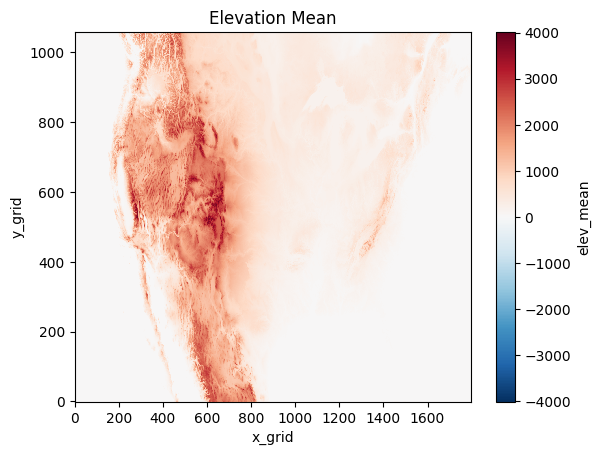

In [6]:
# Using invariant: plot elevation mean for the grid
ds_inv['elev_mean'].plot()
plt.title('Elevation Mean')
plt.show()

## Next Steps
- You can rename or merge variables into a single `xr.Dataset`:
  ```python
  ds = xr.merge([ds_input, ds_output])
  ```
- Reshape `sample` into `(time, y_lr, x_lr)` or `(time, y_hr, x_hr)` by:
  ```python
  ds_input = ds_input.assign_coords(time=ds_input['time'])
  ds_input = ds_input.set_index(sample=['time',])
  ```
- For training workflows, integrate with Modulus CorrDiff pipeline.